In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.models.factory import Experiment
from src.models.linreg import LinearElasticNet
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_test_overlay, plot_val_overlay, \
    plot_val_test_overlay
from src.runners import run_experiments
from src.utils import set_seed
from src.features import create_features_and_target
from src.data import _rename_columns

In [2]:
cfg = Config(Path("../config/config.yaml"))
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
rng = set_seed(SEED)

2025-09-04 14:39:57,314 - INFO - src.utils - Global random seed set to 42


In [3]:
df_price = pd.read_csv(Path(cfg.data.raw_dir) / "djia_table_history.csv")
df_price.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2024-12-31,42636.699219,42779.691406,42421.289062,42544.218750,42544.218750,359210000
1,2024-12-30,42863.859375,42863.859375,42263.511719,42573.730469,42573.730469,383300000
2,2024-12-27,43142.371094,43238.851562,42761.558594,42992.210938,42992.210938,376960000
3,2024-12-26,43201.851562,43373.980469,43115.089844,43325.800781,43325.800781,270350000
4,2024-12-24,42916.480469,43297.648438,42871.761719,43297.031250,43297.031250,230410000


In [4]:
_rename_columns(df_price)
df_full = create_features_and_target(df_price, forecast_horizon=30, training=True)

In [5]:
df_full

,date,open,high,low,close,adj_close,volume,log_return,target_1,target_2,...,open_l,high_l,low_l,close_l,adj_close_l,volume_l,ret_mean_5,ret_std_5,mom_10,dow
7,1992-01-13,3199.500000,3201.250000,3179.110107,3185.600098,3185.600098,19300000,-0.004354,188.443815,37.819003,...,3209.500000,3217.129883,3185.379883,3199.500000,3199.500000,16.969955,-0.000125,0.001945,NaN,0
8,1992-01-14,3185.600098,3248.879883,3182.919922,3246.199951,3246.199951,24220000,0.018844,37.819003,-27.350249,...,3199.500000,3201.250000,3179.110107,3185.600098,3185.600098,16.775616,-0.000908,0.002732,NaN,1
9,1992-01-15,3246.199951,3263.419922,3232.110107,3258.500000,3258.500000,29560000,0.003782,-27.350249,47.278208,...,3185.600098,3248.879883,3182.919922,3246.199951,3246.199951,17.002689,0.002567,0.009407,NaN,2
10,1992-01-16,3258.500000,3262.750000,3222.050049,3249.600098,3249.600098,38100000,-0.002735,47.278208,-33.747539,...,3246.199951,3263.419922,3232.110107,3258.500000,3258.500000,17.201933,0.003380,0.009274,NaN,3
11,1992-01-17,3249.600098,3279.959961,3243.290039,3265.000000,3265.000000,39780000,0.004728,-33.747539,-94.483360,...,3258.500000,3262.750000,3222.050049,3249.600098,3249.600098,17.455725,0.002483,0.009679,0.024044,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8276,2024-11-11,44057.648438,44486.699219,44057.648438,44293.128906,44293.128906,451940000,0.006890,-86.651479,10.745735,...,43768.531250,44157.289062,43733.859375,43988.988281,43988.988281,19.934862,0.009006,0.015830,0.043550,0
8277,2024-11-12,44359.210938,44405.730469,43887.269531,43910.980469,43910.980469,482720000,-0.008665,10.745735,-47.277314,...,44057.648438,44486.699219,44057.648438,44293.128906,44293.128906,19.929060,0.011612,0.013632,0.043974,1
8278,2024-11-13,43880.460938,44141.328125,43829.980469,43958.191406,43958.191406,500190000,0.001075,-47.277314,-70.157549,...,44359.210938,44405.730469,43887.269531,43910.980469,43910.980469,19.994947,0.007845,0.016443,0.038961,2
8279,2024-11-14,44032.378906,44080.781250,43704.820312,43750.859375,43750.859375,545090000,-0.004728,-70.157549,-12.756835,...,43880.460938,44141.328125,43829.980469,43958.191406,43958.191406,20.030499,0.001041,0.006192,0.042205,3


In [6]:
MODEL_NAME = "linreg_wo_sent_prices"

experiments = [
    Experiment(
        name=MODEL_NAME,
        build=lambda horizon, seed: LinearElasticNet(horizon=horizon, random_state=seed, multioutput=True),
        include_sentiment=False
    )
]

In [7]:
results = run_experiments(df_full, Path(cfg.data.processed_dir), experiments, HORIZON, SEED, n_trials=100, n_splits=5)

2025-09-04 14:39:57,838 - INFO - ModelTrainer - Initialized ModelTrainer for model: linreg_wo_sent_prices
2025-09-04 14:40:17,130 - INFO - ModelTrainer - Initialized ModelTrainer for model: linreg_wo_sent_prices
2025-09-04 14:40:17,329 - INFO - ModelTrainer - Evaluating model...


In [8]:
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

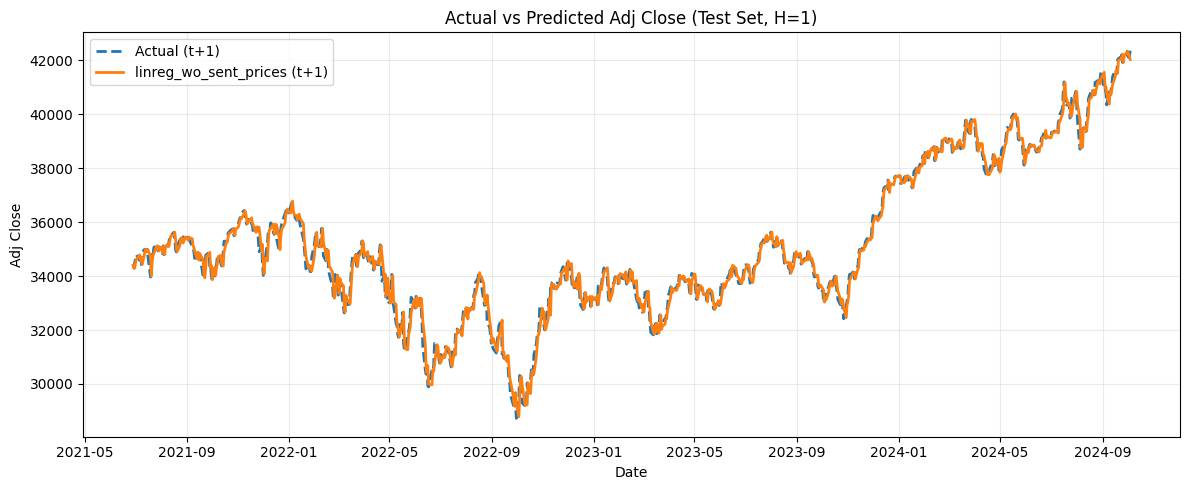

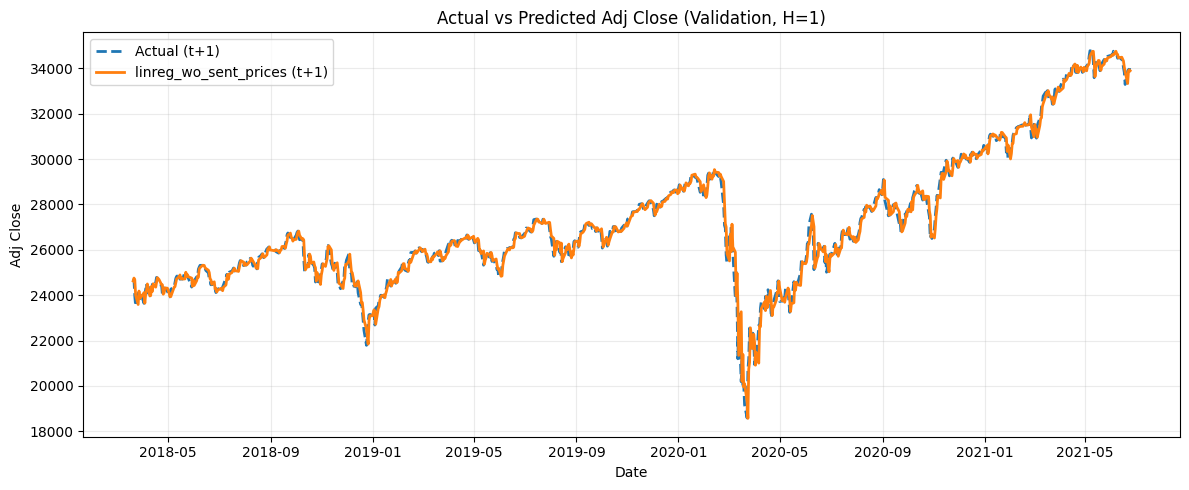

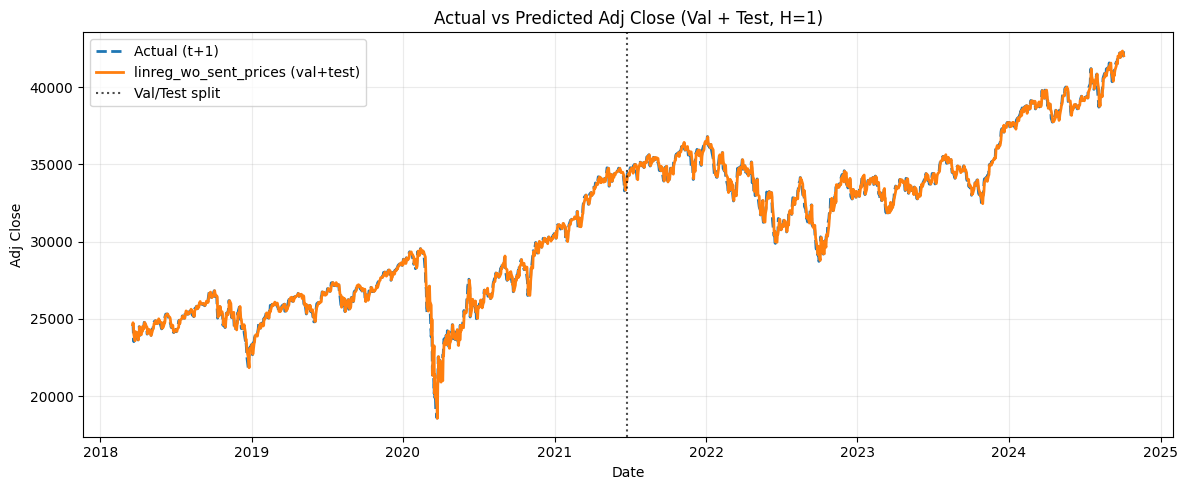

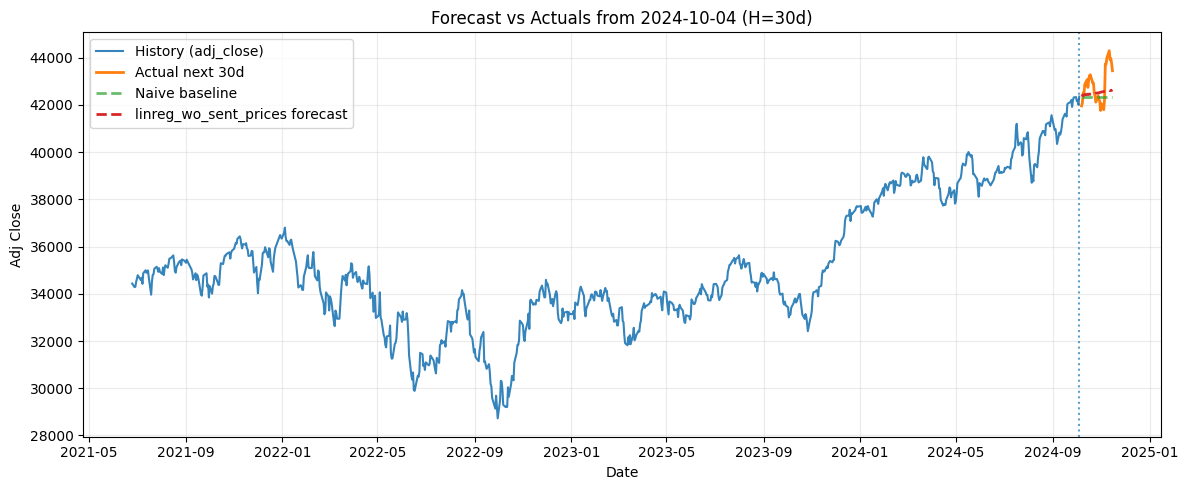

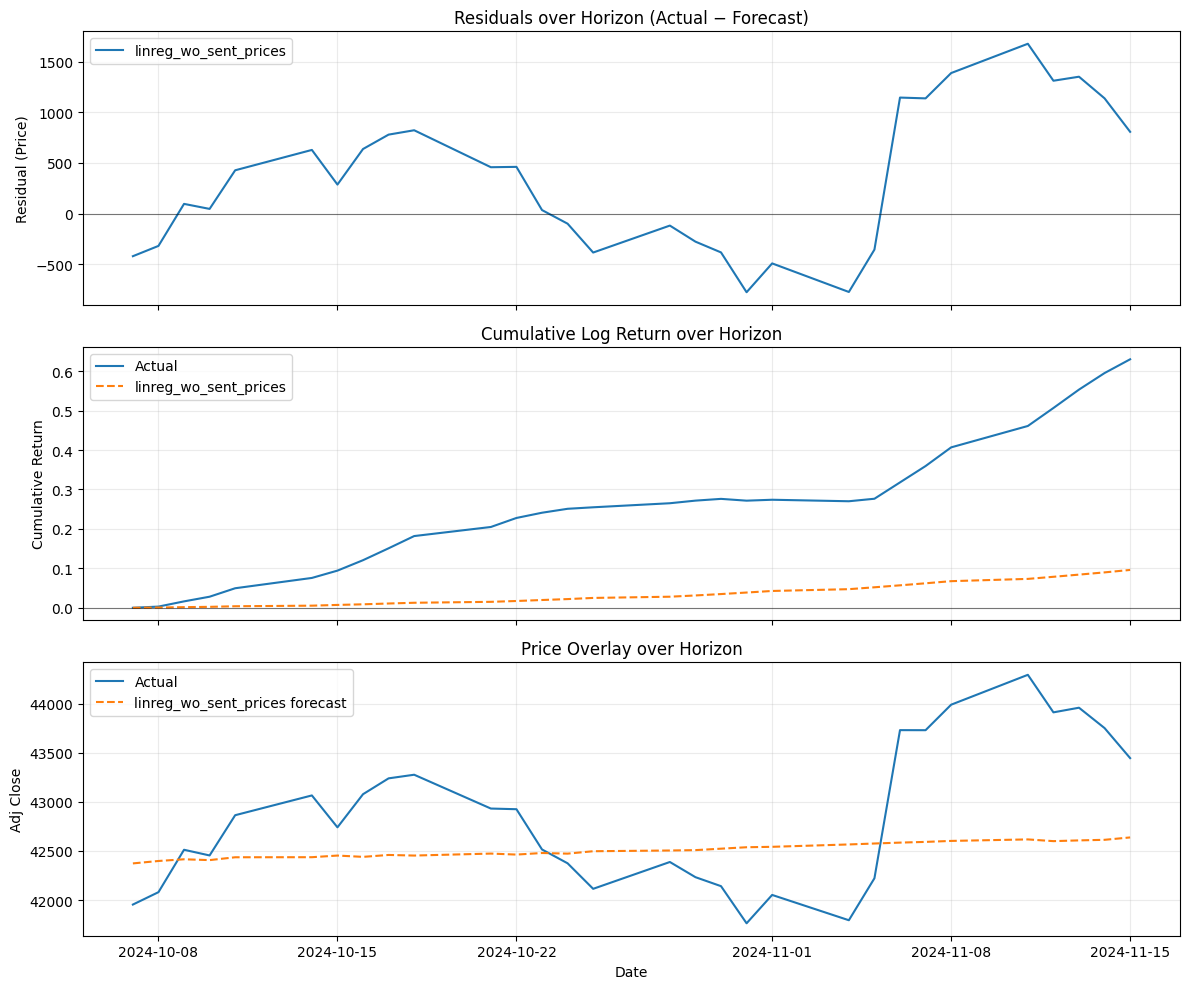

In [9]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val.png")
plot_val_test_overlay(val, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val_test.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast.png")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_diagnostics.png")

In [10]:
pd.DataFrame(results[0]["best_params"], index=[0])

,alpha,l1_ratio,max_iter,selection,random_state
0,0.009676,0.893094,1500,cyclic,42


In [11]:
pd.DataFrame(results[0]["metrics"]["test"], index=[0])

,mae,mse,rmse,smape,r2
0,67.629478,8380.251026,91.543711,1.999922,-0.000764


In [12]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()

In [13]:
import numpy as np

def _ensure_unscaled_lr(arr: np.ndarray) -> np.ndarray:
    """Heuristically ensure daily log-returns are unscaled (~1e-3 magnitude).
    If they look like per-mille (×1000), downscale once. Leaves small values untouched.
    """
    a = np.asarray(arr, dtype=float).ravel()
    if a.size == 0:
        return a
    med = np.median(np.abs(a))
    # Typical daily log-return median is ~1e-3. If >> 0.2, it's almost surely ×1000.
    if med > 0.2:
        a = a / 1000.0
    return a

def as_plot_ready(res: dict, horizon: int) -> dict:
    """Adapt a result dict for your existing plot functions (no plot/runner changes)."""
    out = dict(res)

    # For val/test: take the first horizon (t+1) and ensure unscaled
    def first_horizon(vec):
        if vec is None:
            return None
        arr = np.asarray(vec)
        if arr.ndim == 2:                 # (N, H)
            arr = arr[:, 0]               # t+1 for each row
        arr = arr.ravel()
        return _ensure_unscaled_lr(arr)   # now (N,)

    # For forecast: flatten to (H,) and ensure unscaled
    def h_vector(vec, H):
        if vec is None:
            return None
        arr = np.asarray(vec).ravel()[:H]
        return _ensure_unscaled_lr(arr)   # now (H,)

    out["y_pred_val"]  = first_horizon(out.get("y_pred_val"))
    out["y_pred_test"] = first_horizon(out.get("y_pred_test"))
    out["y_pred_last"] = h_vector(out.get("y_pred_last"), horizon)
    return out


In [14]:
from src.recursive import recursive_forecast


X_forecast = pd.read_parquet(Path(cfg.data.processed_dir) / f"{MODEL_NAME}_X_forecast.parquet")
p0 = float(pd.to_numeric(test["adj_close"], errors="coerce").iloc[-1])
past_prices = test["adj_close"].to_numpy()
linreg_recursive = recursive_forecast(results[0]["trainer"], X_forecast.iloc[[0]], HORIZON, p0=p0, past_prices=past_prices)

In [15]:
res_recursive = {
    "kind": "linreg_recursive_price",
    "horizon": HORIZON,
    "y_pred_val": None,
    "y_pred_test": None,
    "y_pred_last": linreg_recursive,
}
results_to_plot = [results[0], res_recursive]

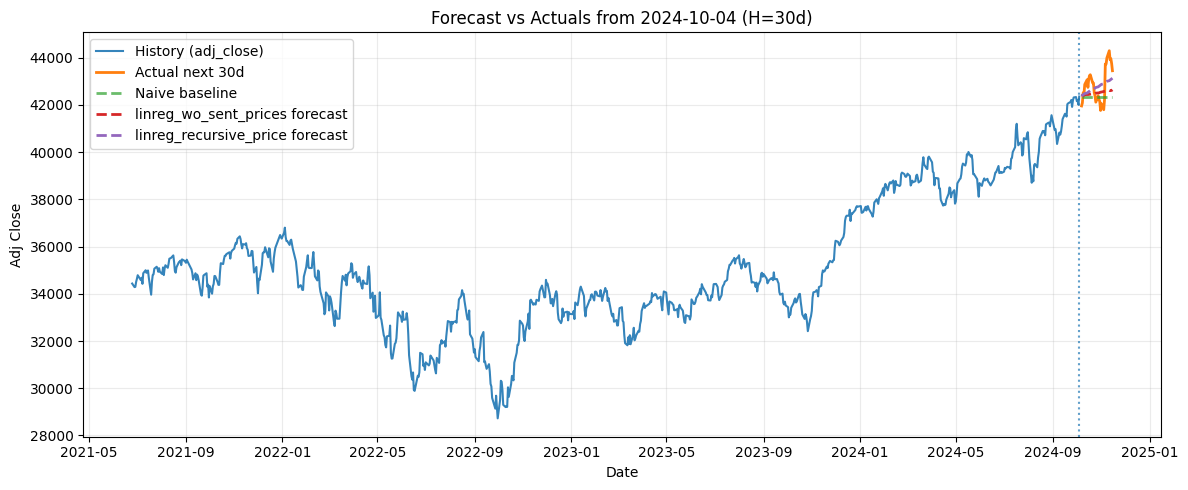

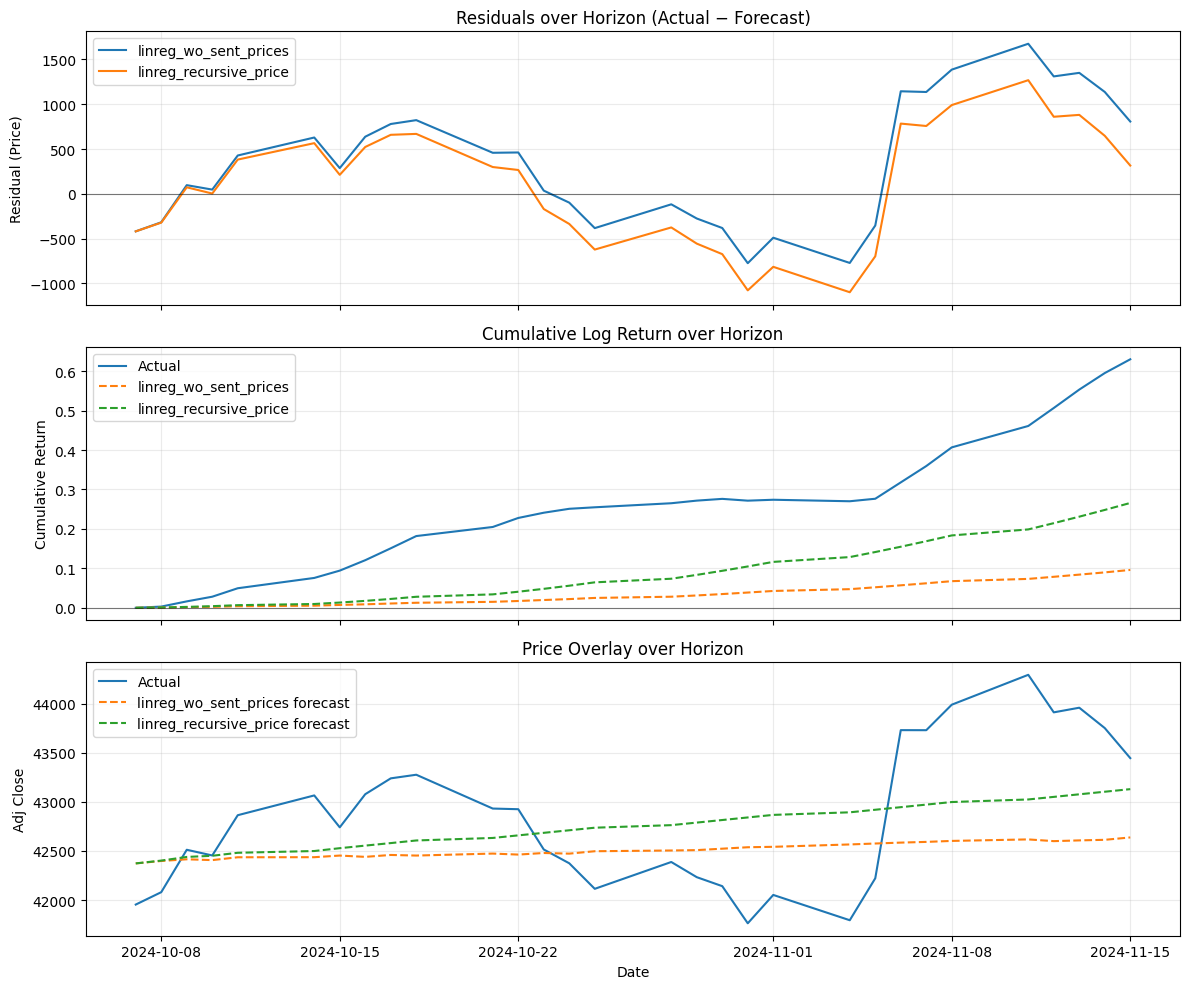

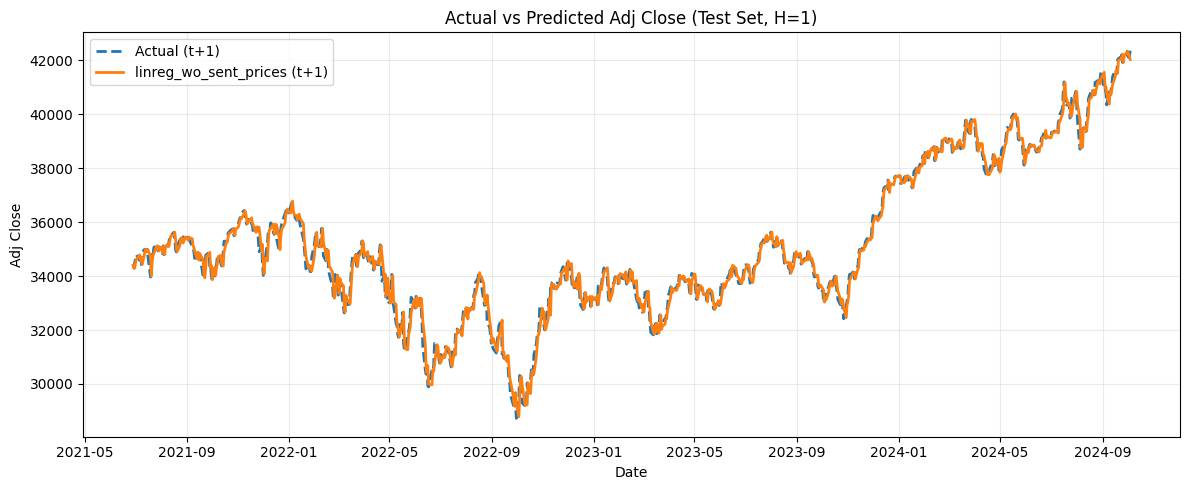

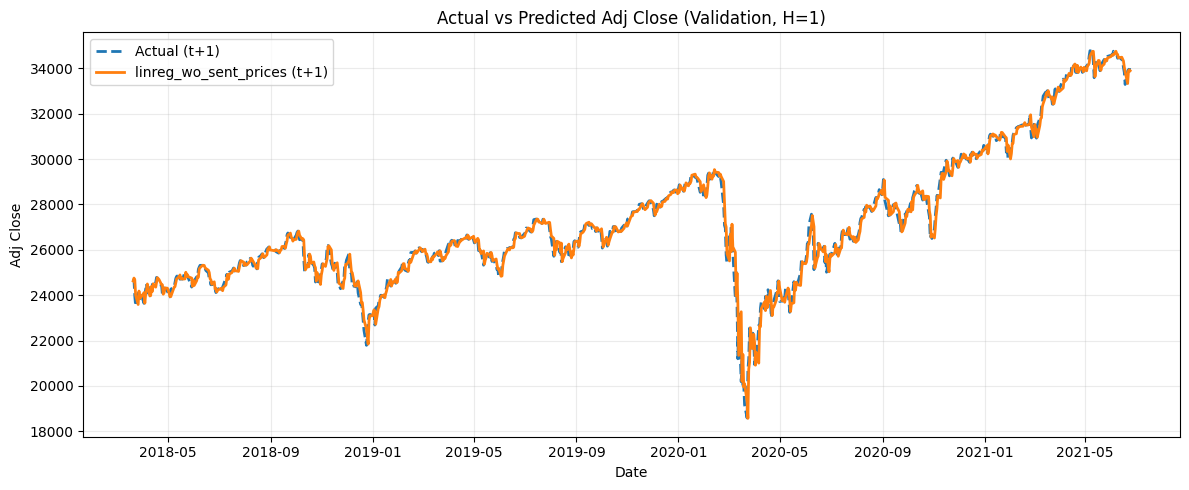

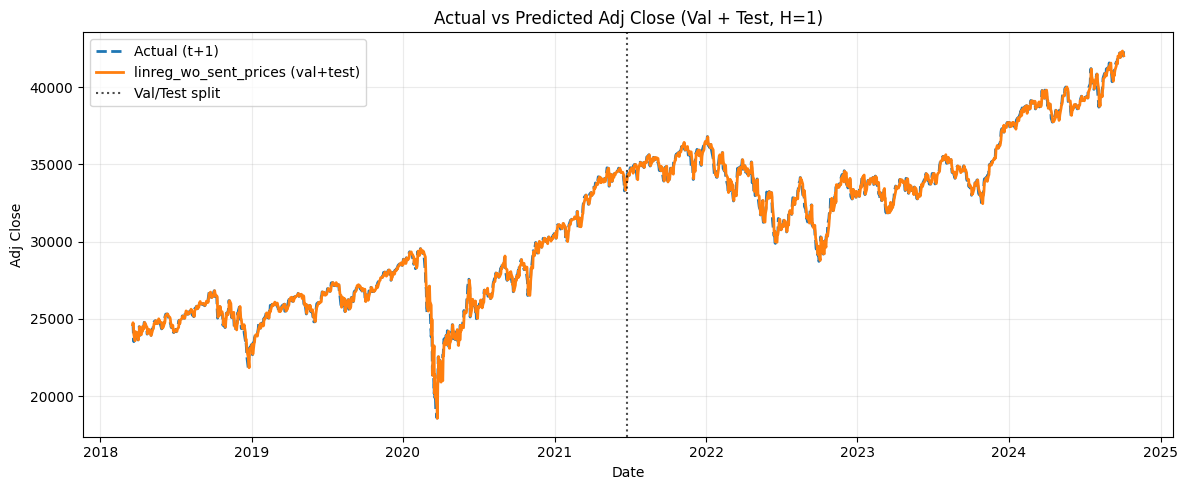

In [16]:
# your existing objects:
# results[0]         -> the direct multioutput model (from runner)
# res_recursive      -> the recursive H-step forecast (your function), (H,) unscaled

results_to_plot = [
    as_plot_ready(results[0], HORIZON),
    as_plot_ready(res_recursive, HORIZON),
]

# now call your existing plotters unchanged:
plot_forecast_overlay(test, forecast, results_to_plot, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_direct_vs_recursive.png")
plot_forecast_diagnostics(forecast, test, results_to_plot, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_diag.png")
plot_test_overlay(test, results_to_plot, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_test_overlay.png")
plot_val_overlay(val, results_to_plot, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_val_overlay.png")
plot_val_test_overlay(val, test, results_to_plot, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_val_test_overlay.png")

In [17]:
dbg = as_plot_ready(results[0], HORIZON)
print("val shape:",  np.asarray(dbg["y_pred_val"]).shape)     # (N,)
print("test shape:", np.asarray(dbg["y_pred_test"]).shape)    # (N,)
print("last shape:", np.asarray(dbg["y_pred_last"]).shape)    # (H,)
print("forecast median |lr|:", np.median(np.abs(dbg["y_pred_last"])))


val shape: (824,)
test shape: (825,)
last shape: (30,)
forecast median |lr|: 0.0003281883042813336
